# Automated Domain Writing: Grid Pulsing with Cypher Image

$_{Yongtao}$ $_{Liu,}$ $_{youngtaoliu@gmail.com}$

$_{March}$ $_{2026}$

### Import 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

from aecroscopywave.wavebuilding import WaveGenerator
from aecroscopywave.interfaces import WaveVI, Cypher

### Initialize Experiment

##### Initialize an instance of PyCypher

In [2]:
pycy = Cypher.PyCypher()

In [3]:
# Test executing Igor Pro commands; you should see messages in Igor Pro's command window
pycy.igor.Execute("Print \"Igor Execute: Hello from Igor Pro!\"")
pycy.Execute("Print \"Execute: Hello from Igor Pro!\"")

'DONE--ExecutePrint "Execute: Hello from Igor Pro!"'

##### Initialize an instance of PyWaveVI

In [ ]:
_path = r'C:\Users\\PyScanner_FPGA_6124_01\PyScanner_FPGA_6124_01.exe'
pyvi = WaveVI.PyWaveVI(app_path = _path)

In [5]:
# Set DAQ settings for PyWaveVI. It takes the default settings in LabView if no argument is provided
pyvi.set_IO_settings(IO_setting_dict ={"trigger_type": 0, "AO_amplifier": 0, "IO_timeout": 5, "AI_ch01": 1, "AI_ch02": 1, "AI_ch03": 1})

'DONE--set_IO_settings'

##### Set a wave

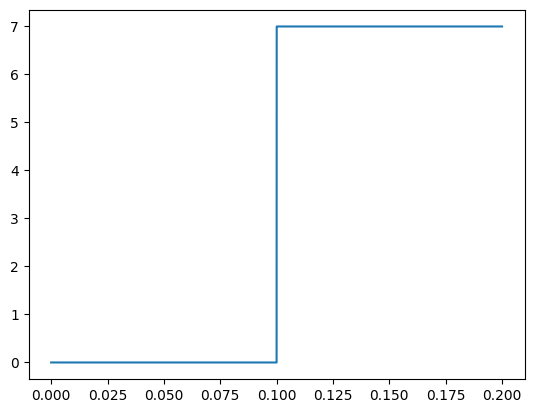

In [6]:
t, backswitchwave = WaveGenerator.square_pulse(amplitude = 7, pulse_duration = [0.1, 0.1, 0])
plt.plot(t, backswitchwave)

##### Upload wave to VI

In [7]:
pyvi.set_AO_waveforms(waveform=backswitchwave, zero_tail=False)

'DONE--set_AO_waveforms'

##### Check uploaded wave

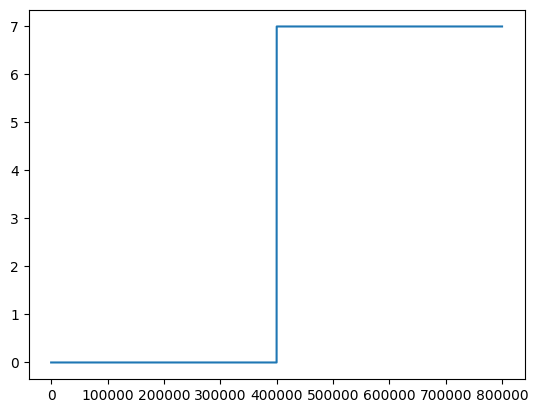

In [8]:
uploadedwave = pyvi.get_AO_waveforms()
plt.plot(uploadedwave)

##### Execute wave

In [9]:
pyvi.set_IO_control(clear = True, upload = True, do_IO = True, fetch_result = False)

'DONE--set_IO_control'

##### Set zero wave

In [11]:
_, setzero = WaveGenerator.square_pulse(amplitude = 0, pulse_duration = [0.1, 0.1, 0.1])

pyvi.set_AO_waveforms(waveform=setzero, zero_tail=False)
pyvi.set_IO_control(clear = True, upload = True, do_IO = True, fetch_result = False)

'DONE--set_IO_control'

##### Move tip

In [25]:
# Initialize tip movement
pycy.initialize_move_tip()

'DONE--initialize move tip'

In [26]:
# Move tip
pycy.move_tip(coordinates = [255, 255], coordinates_type="pixel", transit_time = 0.5)

'DONE--move tip'

### Grid Pulsing

#### Set grid locations

In [13]:
# All locations span across [start_point_x, end_point_x] in x-direction and [start_point_y, end_point_y] in y-direction.
# There are num_x rows and num_y columns in the locations array

start_point_x = 0   # Define location array parameters
end_point_x = 255
start_point_y = 0
end_point_y = 255
num_x = 11
num_y = 11

# Generate location array
pos_x = np.linspace(start_point_x, end_point_x, num_x, dtype = int)
pos_y = np.linspace(start_point_y, end_point_y, num_y, dtype = int)
pulse_pos = np.meshgrid(pos_x, pos_y)
pulse_pos_x = pulse_pos[0].reshape(-1)
pulse_pos_y = pulse_pos[1].reshape(-1)  # pulse_pos_x and pulse_pos_y are the coordinates of all locations

#### Set pulse parameters

In [25]:
# Pulse

start_pulse_v = -3   # Define location array parameters
end_pulse_v = -9
start_pulse_d = 0.05
end_pulse_d = 1.0

# Generate location array
pulse_v = np.linspace(start_pulse_v, end_pulse_v, num_x, dtype = float)
pulse_d = np.linspace(start_pulse_d, end_pulse_d, num_y, dtype = float)
pulse = np.meshgrid(pulse_v, pulse_d)
pulse_v = pulse[0].reshape(-1)
pulse_d = pulse[1].reshape(-1)  # pulse_pos_x and pulse_pos_y are the coordinates of all locations
print (pulse_v)
print(pulse_d)

[-3.  -3.6 -4.2 -4.8 -5.4 -6.  -6.6 -7.2 -7.8 -8.4 -9.  -3.  -3.6 -4.2
 -4.8 -5.4 -6.  -6.6 -7.2 -7.8 -8.4 -9.  -3.  -3.6 -4.2 -4.8 -5.4 -6.
 -6.6 -7.2 -7.8 -8.4 -9.  -3.  -3.6 -4.2 -4.8 -5.4 -6.  -6.6 -7.2 -7.8
 -8.4 -9.  -3.  -3.6 -4.2 -4.8 -5.4 -6.  -6.6 -7.2 -7.8 -8.4 -9.  -3.
 -3.6 -4.2 -4.8 -5.4 -6.  -6.6 -7.2 -7.8 -8.4 -9.  -3.  -3.6 -4.2 -4.8
 -5.4 -6.  -6.6 -7.2 -7.8 -8.4 -9.  -3.  -3.6 -4.2 -4.8 -5.4 -6.  -6.6
 -7.2 -7.8 -8.4 -9.  -3.  -3.6 -4.2 -4.8 -5.4 -6.  -6.6 -7.2 -7.8 -8.4
 -9.  -3.  -3.6 -4.2 -4.8 -5.4 -6.  -6.6 -7.2 -7.8 -8.4 -9.  -3.  -3.6
 -4.2 -4.8 -5.4 -6.  -6.6 -7.2 -7.8 -8.4 -9. ]
[0.05  0.05  0.05  0.05  0.05  0.05  0.05  0.05  0.05  0.05  0.05  0.145
 0.145 0.145 0.145 0.145 0.145 0.145 0.145 0.145 0.145 0.145 0.24  0.24
 0.24  0.24  0.24  0.24  0.24  0.24  0.24  0.24  0.24  0.335 0.335 0.335
 0.335 0.335 0.335 0.335 0.335 0.335 0.335 0.335 0.43  0.43  0.43  0.43
 0.43  0.43  0.43  0.43  0.43  0.43  0.43  0.525 0.525 0.525 0.525 0.525
 0.525 0.525 0.525 0.525

#### Convert pixel coordinates to voltages

In [26]:
pulse_pos_voltages = []  # Convert pixel coordinates to piezo voltages
for i in range(len(pulse_pos_x)):
    pulse_pos_voltages.append(pycy.pixel_to_voltage(pixel_coordinates=[pulse_pos_x[i], pulse_pos_y[i]]))

pulse_pos_voltages

[(np.float64(-0.2569998104894111), np.float64(-1.6403928187319488)),
 (np.float64(-0.16410246298737452), np.float64(-1.6403928187319488)),
 (np.float64(-0.06748922158525605), np.float64(-1.6403928187319488)),
 (np.float64(0.025408125916780655), np.float64(-1.6403928187319488)),
 (np.float64(0.12202136731889895), np.float64(-1.6403928187319488)),
 (np.float64(0.21491871482093566), np.float64(-1.6403928187319488)),
 (np.float64(0.31153195622305385), np.float64(-1.6403928187319488)),
 (np.float64(0.4044293037250906), np.float64(-1.6403928187319488)),
 (np.float64(0.5010425451272089), np.float64(-1.6403928187319488)),
 (np.float64(0.5939398926292457), np.float64(-1.6403928187319488)),
 (np.float64(0.690553134031364), np.float64(-1.6403928187319488)),
 (np.float64(-0.2569998104894111), np.float64(-1.5505021886615555)),
 (np.float64(-0.16410246298737452), np.float64(-1.5505021886615555)),
 (np.float64(-0.06748922158525605), np.float64(-1.5505021886615555)),
 (np.float64(0.025408125916780655)

#### Generate grid points

In [27]:
from typing import Tuple

def generate_grid_points(
    center_offset: Tuple[float, float],
    img_size: float,
    grid_shape: Tuple[int, int] = (10, 10),
    margin: float = 0.0001
) -> np.ndarray:
    """
    Generate a uniform grid of points within the current image area.

    Parameters
    ----------
    center_offset : Tuple[float, float]
        (x, y) offset of the image center in voltage units.
    img_size : float
        Side length of the square image area in voltage units.
    grid_shape : Tuple[int, int], optional
        Number of grid points as (rows, cols). Default is (10, 10).
    margin : float, optional
        Fractional margin to inset from image edges (0.0 = edge-to-edge,
        0.1 = 10% inset on each side). Default is 0.0.

    Returns
    -------
    np.ndarray, shape (N, 2)
        Array of (x, y) voltage coordinates for each grid point,
        ordered row by row (left-to-right, bottom-to-top).

    Examples
    --------
    >>> pts = generate_grid_points(center_offset=(1.0, -0.5), img_size=2.0)
    >>> pts.shape
    (100, 2)
    """
    cx, cy = center_offset
    half = (img_size / 2) * (1.0 - margin)

    x_coords = np.linspace(cx - half, cx + half, grid_shape[0])
    y_coords = np.linspace(cy - half, cy + half, grid_shape[1])

    xx, yy = np.meshgrid(x_coords, y_coords)

    # Flatten to (N, 2) array of (x, y) pairs
    grid_points = np.column_stack([xx.ravel(), yy.ravel()])
    return grid_points

In [28]:
metadata = pycy.get_MasterVariables()
metadata

{'ScanSize': 4e-06,
 'FastScanSize': 4e-06,
 'SlowScanSize': 4e-06,
 'ScanRate': 1.001602564102564,
 'ScanSpeed': 1.0016025641025641e-05,
 'XOffset': -1.533311e-06,
 'YOffset': 7.874228900000001e-08,
 'ScanPoints': 256.0,
 'ScanLines': 256.0,
 'RoundFactor': 0.04,
 'IntegralGain': 30.0,
 'ProportionalGain': 0.0,
 'ScanAngle': 0.0,
 'ScanAngleFactor': 1.0,
 'AmplitudeSetpointVolts': 0.8,
 'AmplitudeSetpointMeters': 1e-08,
 'DriveAmplitude': 1.0,
 'DriveFrequency': 49999.99888241291,
 'SweepWidth': 200000.0,
 'SlowScanEnabled': 1.0,
 'DeflectionSetpointVolts': 1.0,
 'DeflectionSetpointMeters': 0.0,
 'DeflectionSetpointNewtons': 5e-09,
 'ImagingMode': 3.0,
 'MaxScanSize': 3e-05,
 'InvOLS': 5.104461353927852e-07,
 'SpringConstant': 1.0,
 'DisplaySpringConstant': 1e-09,
 'ScanStateChanged': 0.0,
 'ScanDown': 0.0,
 'XLVDTSens': 4.2214e-06,
 'YLVDTSens': 4.3626e-06,
 'ZLVDTSens': 2.45e-06,
 'XLVDTOffset': 0.58,
 'YLVDTOffset': -1.2,
 'ZLVDTOffset': 0.0,
 'YIgain': 4.84,
 'YPgain': -inf,
 'XIg

In [29]:
CenterX, CenterY = metadata['XOffset'], metadata['YOffset']

In [30]:
pts = generate_grid_points(center_offset=(metadata['XOffset'], metadata['YOffset']), grid_shape=(num_x, num_y), img_size=4e-6)
pts.shape

(121, 2)

#### Start grid pulsing

In [31]:
# Initialize tip movement
pycy.initialize_move_tip()
pycy.engage()

for i in range(len(pulse_pos_x)):
    #####################---Move tip to the pulse location---#####################
    pycy.PV(parameters = {'DriveAmplitude': 0})
    time.sleep(2)
    pycy.initialize_move_tip()
    time.sleep(1)
    pycy.move_tip(coordinates = [pulse_pos_voltages[i][0], pulse_pos_voltages[i][1]], coordinates_type="voltage", transit_time = 0.5)
    time.sleep(0.5)
    #####################---Apply pulse---##################### 
    pycy.engage()
    _, square_wave = WaveGenerator.square_pulse(amplitude = pulse_v[i], pulse_duration = [0.2, pulse_d[i], 0.2])
    pyvi.set_AO_waveforms(waveform=square_wave, zero_tail=False)
    time.sleep(1)
    pyvi.set_IO_control(clear = True, upload = True, do_IO = True, fetch_result = False)
    time.sleep(1)

    #####################---Set image parameter, particular center offset---#####################
    params = { 'DriveAmplitude': 1, "ScanSize": 3.5e-7, "ScanPoints": 64, "ScanLines": 64, "ScanRate": 1, 
                  'XOffset': pts[i,0], 'YOffset': pts[i,1]}
    pycy.set_Master_Panel(parameters=params, do_scan="Frame Up")

In [34]:
params = { 'DriveAmplitude': 1, "ScanSize": 5e-6, "ScanPoints": 512, "ScanLines": 512, "ScanRate": 1, 
          'XOffset': CenterX, 'YOffset': CenterY}
pycy.set_Master_Panel(parameters=params, do_scan="Frame Down")

'DONE--set Master Panel'

### Save Data

In [32]:
np.savez('pulse.npz', pulse_v = pulse_v, pulse_d = pulse_d)

In [33]:
import json
metadata = pycy.get_MasterVariables()

# Save
with open("metadata.json", "w") as f:
    json.dump(metadata, f)
